## 1. Toy-problem

### 1.1 Problem context and set up

Given past history of order flow, how are we - as a market maker - able to tell the difference between noise and informed flow? For example, we may observe a sequence consisting of an overwhelmingly majority of buys, leading to an increasingly short inventory. If the event is truly noise, then we expect our inventory to revert back to its optimal amount based on our current strategy. But if our short inventory is due to informed buying, then our inventory will be even more increasingly short. 

We can start with a toy problem. First, let us represent each buy and sell as the i.i.d. random variable $X_i$. $X_i$ can be interpreted as the signed trade of the $i$-th trade; it tells us the direction and quantity of the $i$-th trade.

$$ 
X_i = \begin{cases}
    +1 &i\text{-th trade } \text{ is a buy of 1 unit} \\
    -1 &i\text{-th trade } t \text{ is a sell of 1 unit}
\end{cases}
$$

where $i = 1, 2, ...$. Then the cumulative order flow is $S_n = \sum_{i=1}^n X_i$ and is interpreted as the net signed order flow after $n$ trades.

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

def cum_ord_flow(n, p):
    """
    Inputs:
    n: number of trades
    p: probability of buy (independent of time)

    Outputs: 
    X = signed trade 
    S = cumulative order flow after n trades
    """

    # probability must be between 0 and 1
    if not 0 <= p <= 1:
        raise ValueError("p must be between 0 and 1.")

    # X_i
    X = np.random.choice([-1, 1], size = n-1, p = [1-p, p])

    # cumulative order flow
    S = np.zeros(n)

    for i in range(n-1):
        S[i+1] = S[i] + X[i]

    return X, S

### 1.2 Simple qualitative exploration using symmetric probabilities for fixed $n$

We first assume that $\mathbb{P}(\text{trade } i \text{ is a buy}) = p = 0.5$ and hence $\mathbb{P}(\text{trade } i \text{ is a sell}) = q = 1-p = 0.5$ and use $n = 10,000$ trades/steps. 

Under these probabilities, our cumulative order flow $S_n$ is a symmetric random walk. 

We first explore by simulating $N = 10$ different sample paths to qualitatively understand the variability of cumulative order flow given the same market structure.

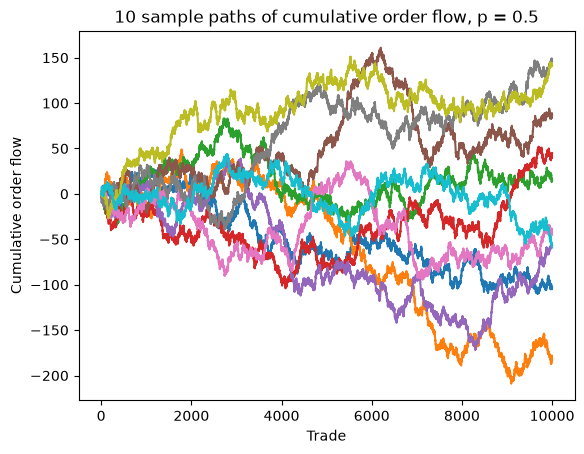

In [2]:
# cumulative order flow simulation under equal probabilities and n = 10000 steps
n = 10**4
p = 0.5

# plotting N = 10 different sample paths
N = 10
for i in range(N):
    # cumulative sample paths
    X, S = cum_ord_flow(n = n, p = p)
    plt.plot(np.arange(n), S)

# plotting cumulative order flow
plt.title(f"10 sample paths of cumulative order flow, p = {p}")
plt.xlabel("Trade")
plt.ylabel("Cumulative order flow")
plt.show()

We can run the above code many times and observe that the 10 sample paths generate quite variable paths. For some runs, the majority of the paths have negative cumulative order flow whereas for other runs, the signs cumulative order flow quite evenly spread throughout. If cumulative order flow is truly noise with symmetric probabilities and $n = 10,000$, the sample paths can vary quite a lot. As a result, it will be difficult to tell the difference between noise and informed buying as large cumulative imbalances can arise from noise as seen in the simulation.

Now we use larger $N = 1,000$ to explore the empirical distribution of the terminal value of our cumulative order flow under the same, fixed $p = 0.5$ and $n = 10,000$. We'll also plot the theoretical distribution which is derived below.

Recall the i.i.d random variable $X_i$ is

$$ 
X_i = \begin{cases}
    +1 &\mathbb{P}(i\text{-th trade } \text{ is a buy of 1 unit}) = p \\
    -1 &\mathbb{P}(i\text{-th trade } \text{ is a sell of 1 unit}) = 1 - p
\end{cases}
$$

Then the first moment is, 

\begin{align*}
    \mathbb{E}(X_i) 
        &= 1 \cdot p + (-1) \cdot (1 - p) \\
        &= 2p - 1
\end{align*}

We also have the second moment 

\begin{align*}
    \mathbb{E}(X_i^2) 
        &= (1)^2 \cdot p + (-1)^2 \cdot (1-p) \\
        &= 1
\end{align*}

Therefore the variance is 

\begin{align*}
    \mathbb{V}\text{ar}(X_i) 
        &= \mathbb{E}(X_i^2) - \mathbb{E}(X_i)^2 \\
        &= 1 - (2p - 1)^2 \\ 
        &= -4p^2 + 4p \\
        &= 4p(1 - p)
\end{align*}

Also $S_n = \sum_{i=1}^n X_i$. By linearity and identicalness, 

$$\mathbb{E}(S_n^{(j)}) = n(2p-1) \text{ and } \mathbb{V}\text{ar}(S_n^{(j)}) = 4np(1-p)$$

for all $j = 1, 2, ..., N$.

For large $n$, by the Central Limit Theorem, $S_n^{(j)} \sim \mathcal{N}(n(2p-1), 4np(1-p))$ approximately. 

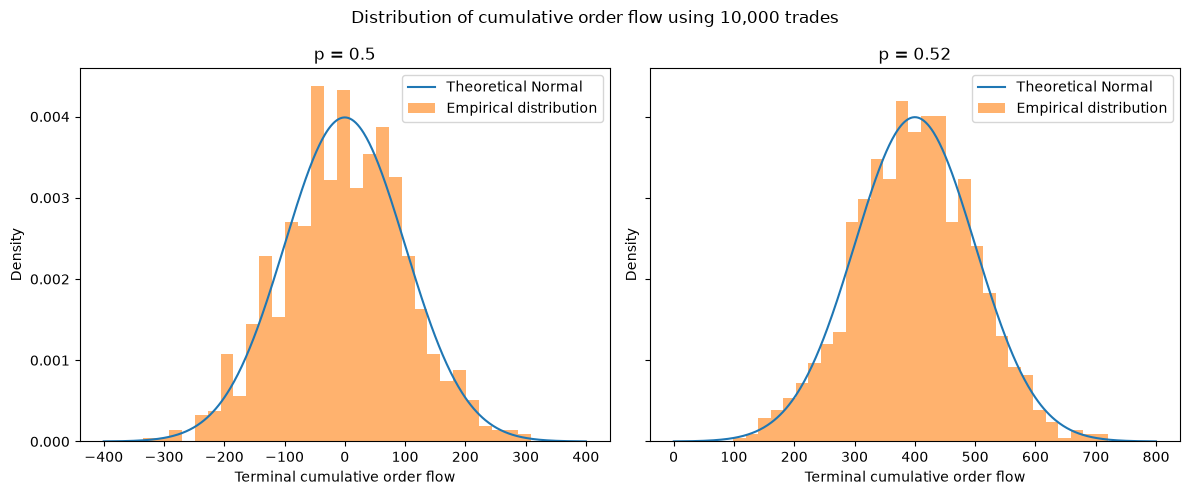

In [3]:
# library
from scipy.stats import norm

#  function that plots distribution of terminal values
def plot_terminal_distribution(N, n, p, ax, bins = 30):
    """
    Inputs:
    N: number of sample paths
    n: number of trades
    p: probability of a buy
    ax: subplot to plot on
    bins: number of histogram bins

    Outputs:
    Plots distribution of cumulative order flow terminal values 
    """

    # empirical distribution of terminal values
    term_values = np.zeros(N)

    for i in range(N):
        # cumulative sample paths
        term_values[i] = cum_ord_flow(n = n, p = p)[1][-1]

    # theoretical normal statistics
    mu = n * (2 * p - 1)
    sigma = np.sqrt(4 * n * p * (1 - p))

    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
    y = norm.pdf(x, loc = mu, scale = sigma)

    # plotting

    # normal distribution
    ax.plot(x, y, label = "Theoretical Normal")

    # empirical distribution
    ax.hist(term_values, bins = bins, density = True, alpha = 0.6, label = "Empirical distribution")

    ax.set_title(f"p = {p}")
    ax.set_xlabel("Terminal cumulative order flow")
    ax.set_ylabel("Density")
    ax.legend()

# plotting using N = 1000, n = 10000, p = 0.5 and 0.52
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharey = True)

plot_terminal_distribution(N = 1000, n = 10000, p = 0.5, ax = axes[0])
plot_terminal_distribution(N = 1000, n = 10000, p = 0.52, ax = axes[1])

fig.suptitle("Distribution of cumulative order flow using 10,000 trades")

plt.tight_layout()
plt.show()

There is quite a lot of variability between the individual sample paths as seen in the previous plot. Despite this, when we look at the terminal values across many paths, they are approximately normally distributed around 0 (left histogram). This shows that a path can have periods of quite strong buying or selling even when there is no actual bias in the underlying order flow (i.e. when $p = 0.5$). So if we observe what looks like strong buying, this alone isn't enough to say that informed buying is occurring — it could just be noise from a symmetric order flow process.

Comparing the theoretical distributions of terminal cumulative order flow for $n = 10,000$ and $p = 0.5$ vs. $p = 0.52$, we get that $S_n^{(j)} \sim \mathcal{N}(0, 100)$ and $S_n^{(j)} \sim \mathcal{N}(400, 99.84)$ respectively. 

Comparing the distribution of the terminal cumulative order flows of these two models, the main difference is the mean as the theoretical variance is quite similar. We expect (on average) that a model with stronger buy-side bias will have higher terminal cumulative order flow compared to a model with no bias (i.e. symmetric probability $p = 0.5$).

### 1.3 Varying probabilities $p$ with fixed $n$

We now start to explore what happens to our sample paths when we vary the probability $p$ using some fixed $n$. 

The values of $p$ are chosen to represent increasingly strong buy-side biases (i.e. $p \geq 0.5$). The same values will be used across each $n$ so that the effect of changing the number of observed trades can be compared directly. 

This will allow us to better understand how our model parameters affect our model. Despite being only a toy-problem, this exploration will give a stronger basic understanding of the problem, our model, and its moving parts. 


In [4]:
# function that plots the cumulative order flows using different N, n, and p
def plot_cum_order_flow(N, n, probs):
    """
    Inputs:
    N: number of sample paths
    n: number of trades
    probs: probabilities of a buy

    Outputs:
    2x2 plot of 10 sample paths under different probabilities
    """

    # cumulative order flow simulation under different probabilities

    fig, axes = plt.subplots(2, 2, figsize = (12, 8), sharex = True, sharey = True)

    # for different p
    for ax, p in zip(axes.flat, probs):

        # plotting N different sample paths for different values of p
        for i in range(N):

            # cumulative sample paths
            X, S = cum_ord_flow(n = n, p = p)

            ax.plot(np.arange(n), S)

        # plotting cumulative order flow
        ax.set_title(f"p = {p}")
        ax.set_xlabel("Trade")
        ax.set_ylabel("Cumulative order flow")

    fig.suptitle(f"{N} sample paths of cumulative order flow using {n} trades")

    plt.tight_layout()
    plt.show()

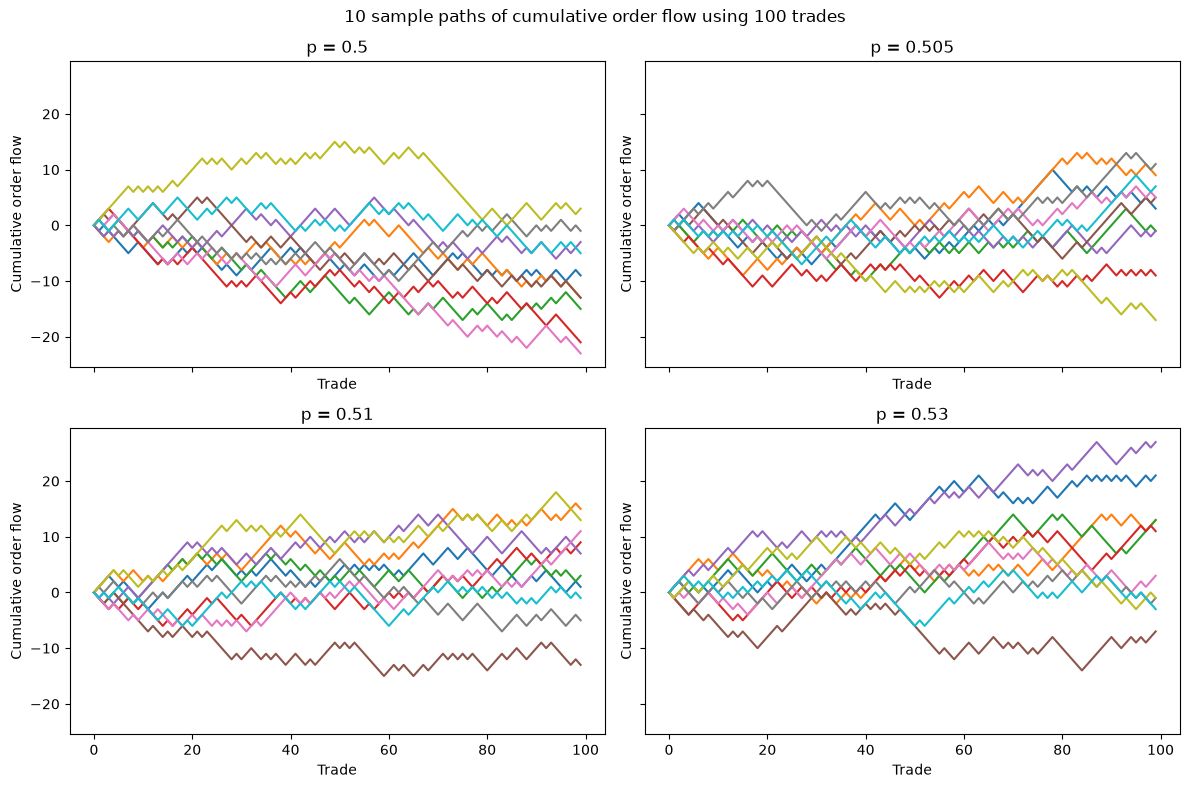

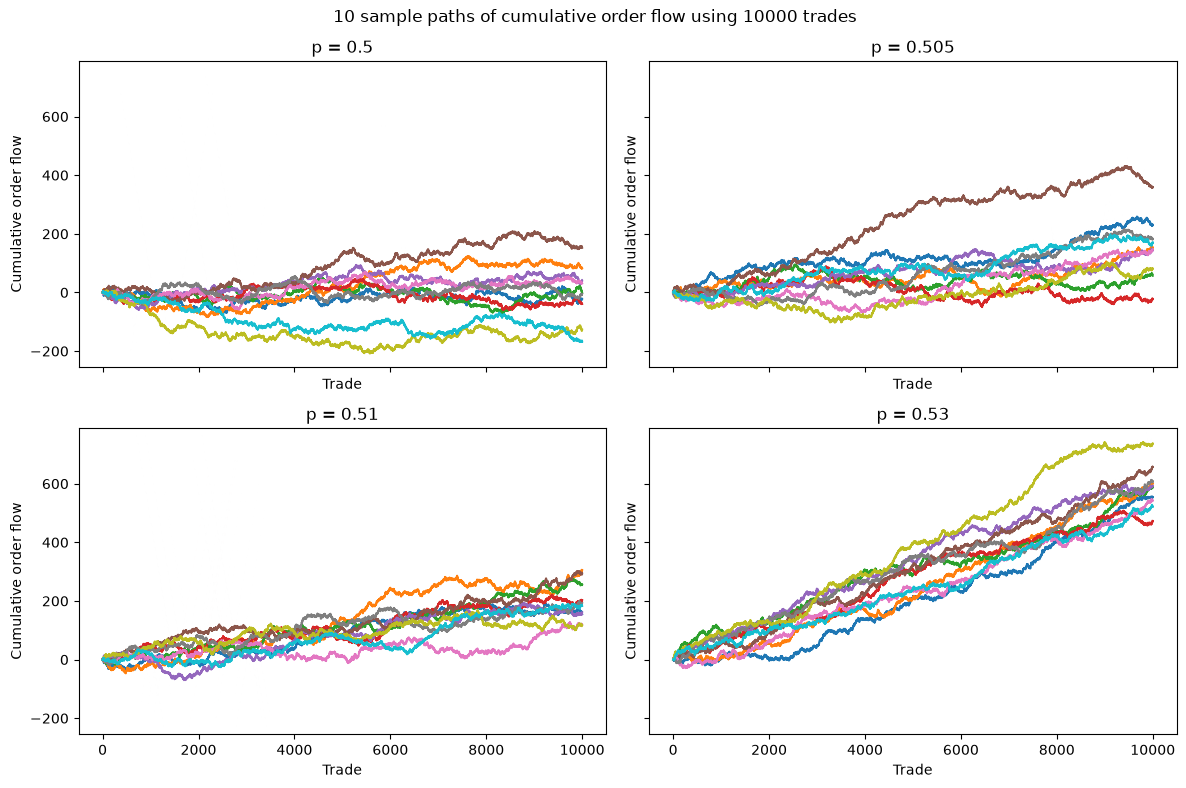

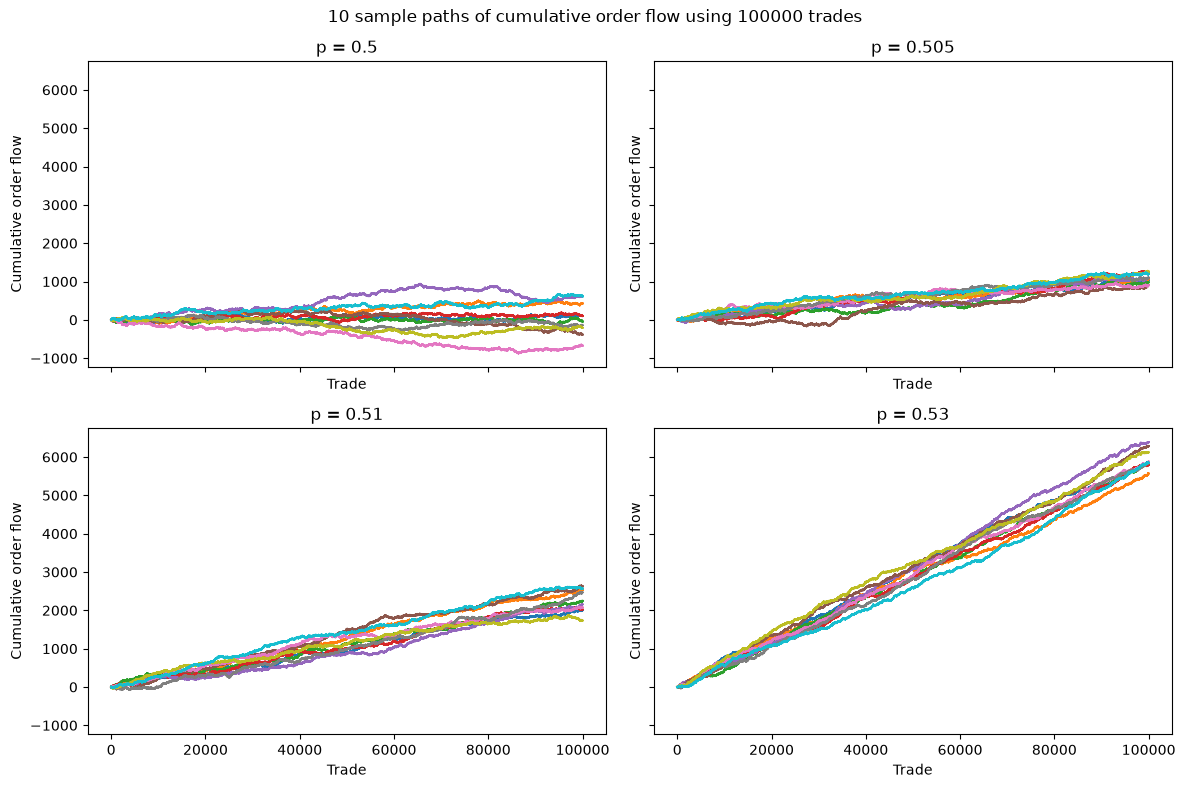

In [5]:
# same probabilities across n = 100, 1000, 10000 trades
probs = np.array([0.5, 0.505, 0.51, 0.53])

plot_cum_order_flow(N = 10, n = 10**2, probs = probs)
plot_cum_order_flow(N = 10, n = 10**4, probs = probs)
plot_cum_order_flow(N = 10, n = 10**5, probs = probs)

- The probabilities across different $n$ were kept constant to explore how varying the probabilities affected the cumulative order flow.
- For lower $n$, it is difficult to distinguish the difference between sample paths under different probabilities. 
- This can be observed in the $n = 100$ case, where the sample paths for different probabilities are extremely similar. 
- As $n$ increases, the sample paths under different probabilities start to become increasingly easier to distinguish. Take $n = 100,000$ for example; the sample paths with symmetric probability $p = 0.5$ looks relatively flat compared to when $p = 0.53$. The distinguishable characteristics between sample paths for any fixed $n$ start to become apparent and obvious as $n$ increases. 
- Intuitively, this is because for over a larger amount of trades $n$, the buy-bias has the ability to compound more aggressively. As a result, the drift introduced in the model from the asymmetric probability compounds additively which is observed as a strong linear upward trend. 

There's two things I want to discuss here: 
1. Between different $n$, and
2. Within certain fixed $n$

It's difficult to separate between and within discussion...

### 1.4 Toy-problem takeaways and limitations

Takeaways:
1. Introducing buying-bias via $p > 0.5$ introduces drift into the model which, depending on the number of trades $n$ that is used, affects the cumulative order flow differently.  
2. Model with no buying-bias $p = 0.5$ exhibits high variance and can still produce paths that exhibit strong periods of buying. Hence, simply observing paths that have strong periods of buying isn't sufficient in concluding that informed buying has occurred. 

Limitations:
1. $X_i$ are i.i.d / trades are i.i.d: an example of why this isn't realistic would be period of strong selling. Large sale of an asset can signal to market participants that the asset is overpriced, hence causing a chain of selling frenzy. i.e. trades are not independent. 
2. Indices are over trade amounts instead of time: we can interpret trade number as time but this then assumes that at each time only buy of 1 unit or sell of 1 unit is possible
3. Assume that each trade is only either a buy or sell of 1 unit: market participants are able to purchase or sell more than 1 unit in a singular transaction
4. $p_i = p$: assumes constant market regime
5. Model does not include any price information